# Step 5: Data Wrangling & Exploratory Data Analysis

## Customer Churn Capstone

This notebook prepares the customer churn dataset for machine learning. The goal is to inspect the raw data, identify data quality issues, clean unnecessary fields, explore relationships between variables, encode categorical features, evaluate possible outliers, and export a cleaned dataset for model development.

The dataset used in this project is a bank customer churn dataset. The target variable is `Exited`, where `0` means the customer remained with the bank and `1` means the customer exited/churned.

## 1. Import Libraries

The project uses pandas and NumPy for data manipulation and Matplotlib for visualization. Scikit-learn preprocessing tools are imported for preparing the dataset for future modeling steps.

In [3]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt

# Preprocessing
from sklearn.preprocessing import StandardScaler

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

print('Libraries loaded successfully.')

Libraries loaded successfully.


## 2. Load Dataset

The raw dataset is loaded from the CSV file included in the project repository.

In [4]:
# Load the dataset
file_path = 'Customer Churn new.csv'
df = pd.read_csv(file_path)

print('Dataset loaded successfully.')
print(f'Rows: {df.shape[0]}')
print(f'Columns: {df.shape[1]}')

df.head()

Dataset loaded successfully.
Rows: 10000
Columns: 11


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,EstimatedSalary,Exited
0,747,15787619,Hsieh,844,France,Male,18,2,"160,980.03","145,936.28",0
1,1620,15770309,McDonald,656,France,Male,18,10,"151,762.74","127,014.32",0
2,1679,15569178,Kharlamov,570,France,Female,18,4,"82,767.42","71,811.90",0
3,2022,15795519,Vasiliev,716,Germany,Female,18,3,"128,743.80","197,322.13",0
4,2137,15621893,Bellucci,727,France,Male,18,4,"133,550.67","46,941.41",0


## 3. Initial Data Inspection

Before cleaning, the dataset structure, data types, descriptive statistics, missing values, and duplicate records are reviewed.

In [5]:
# Review column names and data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   EstimatedSalary  10000 non-null  float64
 10  Exited           10000 non-null  int64  
dtypes: float64(2), int64(6), object(3)
memory usage: 859.5+ KB


In [6]:
# Summary statistics for numerical columns
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,EstimatedSalary,Exited
count,"10,000.00","10,000.00","10,000.00","10,000.00","10,000.00","10,000.00","10,000.00","10,000.00"
mean,"5,000.50","15,690,940.57",650.53,38.92,5.01,"76,485.89","100,090.24",0.20
std,"2,886.90","71,936.19",96.65,10.49,2.89,"62,397.41","57,510.49",0.40
min,1.00,"15,565,701.00",350.00,18.00,0.00,0.00,11.58,0.00
25%,"2,500.75","15,628,528.25",584.00,32.00,3.00,0.00,"51,002.11",0.00
50%,"5,000.50","15,690,738.00",652.00,37.00,5.00,"97,198.54","100,193.91",0.00
75%,"7,500.25","15,753,233.75",718.00,44.00,7.00,"127,644.24","149,388.25",0.00
max,"10,000.00","15,815,690.00",850.00,92.00,10.00,"250,898.09","199,992.48",1.00


In [7]:
# Check missing values
missing_values = df.isnull().sum().sort_values(ascending=False)
missing_values

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
EstimatedSalary    0
Exited             0
dtype: int64

In [8]:
# Check duplicate rows
duplicate_rows = df.duplicated().sum()
print(f'Duplicate rows: {duplicate_rows}')

Duplicate rows: 0


### Initial Data Quality Findings

The dataset contains 10,000 records and 11 columns. The initial inspection checks whether any missing values or duplicate rows require correction before modeling. Identifier fields such as `RowNumber`, `CustomerId`, and `Surname` are also reviewed because they do not represent meaningful customer behavior for prediction.

## 4. Target Variable Review

The target variable is `Exited`. This column indicates whether the customer churned.

- `0` = customer stayed
- `1` = customer exited/churned

In [9]:
# Target distribution
target_counts = df['Exited'].value_counts().sort_index()
target_percent = df['Exited'].value_counts(normalize=True).sort_index() * 100

target_summary = pd.DataFrame({
    'Count': target_counts,
    'Percentage': target_percent.round(2)
})

target_summary

,Count,Percentage
Exited,,
0,7963,79.63
1,2037,20.37


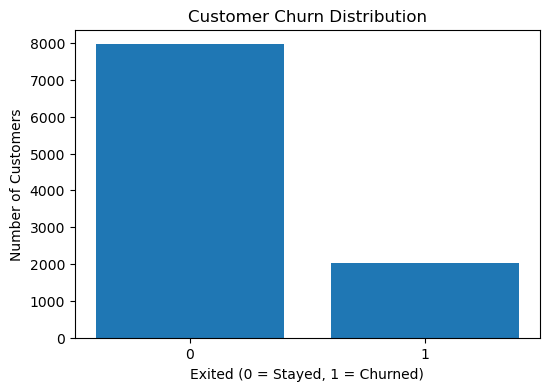

In [10]:
# Plot churn distribution
plt.figure(figsize=(6, 4))
plt.bar(target_counts.index.astype(str), target_counts.values)
plt.title('Customer Churn Distribution')
plt.xlabel('Exited (0 = Stayed, 1 = Churned)')
plt.ylabel('Number of Customers')
plt.show()

### Target Variable Finding

The target variable is imbalanced, with more customers staying than exiting. This is realistic for churn problems because most customers typically do not churn during a given observation period. Because of this imbalance, future model evaluation should consider precision, recall, F1-score, and ROC-AUC rather than relying on accuracy alone.

## 5. Remove Non-Predictive Identifier Columns

The columns `RowNumber`, `CustomerId`, and `Surname` uniquely identify records or customers but do not provide meaningful predictive value. Including these fields could introduce noise or cause the model to learn patterns that do not generalize.

In [11]:
# Drop non-predictive identifier columns
df_clean = df.drop(columns=['RowNumber', 'CustomerId', 'Surname'])

print(f'Original shape: {df.shape}')
print(f'Cleaned shape after dropping identifier columns: {df_clean.shape}')

df_clean.head()

Original shape: (10000, 11)
Cleaned shape after dropping identifier columns: (10000, 8)


,CreditScore,Geography,Gender,Age,Tenure,Balance,EstimatedSalary,Exited
0,844,France,Male,18,2,"160,980.03","145,936.28",0
1,656,France,Male,18,10,"151,762.74","127,014.32",0
2,570,France,Female,18,4,"82,767.42","71,811.90",0
3,716,Germany,Female,18,3,"128,743.80","197,322.13",0
4,727,France,Male,18,4,"133,550.67","46,941.41",0


## 6. Categorical Feature Exploration

The dataset contains categorical variables that must be encoded before modeling. The two categorical variables are `Geography` and `Gender`.

In [12]:
# Review categorical columns
categorical_columns = df_clean.select_dtypes(include=['object']).columns.tolist()
print('Categorical columns:', categorical_columns)

for col in categorical_columns:
    print()
    print(f'{col} value counts:')
    print(df_clean[col].value_counts())

Categorical columns: ['Geography', 'Gender']

Geography value counts:
Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

Gender value counts:
Gender
Male      5457
Female    4543
Name: count, dtype: int64


In [13]:
# Churn rate by Geography
geo_churn = df_clean.groupby('Geography')['Exited'].mean().sort_values(ascending=False) * 100
geo_churn

Geography
Germany   32.44
Spain     16.67
France    16.15
Name: Exited, dtype: float64

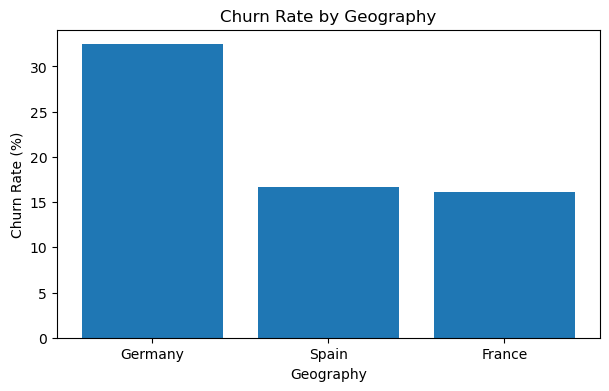

In [14]:
# Plot churn rate by Geography
plt.figure(figsize=(7, 4))
plt.bar(geo_churn.index, geo_churn.values)
plt.title('Churn Rate by Geography')
plt.xlabel('Geography')
plt.ylabel('Churn Rate (%)')
plt.show()

In [15]:
# Churn rate by Gender
gender_churn = df_clean.groupby('Gender')['Exited'].mean().sort_values(ascending=False) * 100
gender_churn

Gender
Female   25.07
Male     16.46
Name: Exited, dtype: float64

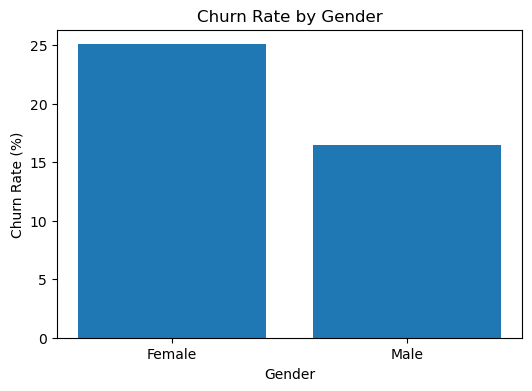

In [16]:
# Plot churn rate by Gender
plt.figure(figsize=(6, 4))
plt.bar(gender_churn.index, gender_churn.values)
plt.title('Churn Rate by Gender')
plt.xlabel('Gender')
plt.ylabel('Churn Rate (%)')
plt.show()

## 7. Numerical Feature Exploration

Numerical features are examined to understand their distributions and potential relationship with churn.

In [17]:
# Identify numerical columns
numerical_columns = df_clean.select_dtypes(include=['int64', 'float64']).columns.tolist()
print('Numerical columns:', numerical_columns)

Numerical columns: ['CreditScore', 'Age', 'Tenure', 'Balance', 'EstimatedSalary', 'Exited']


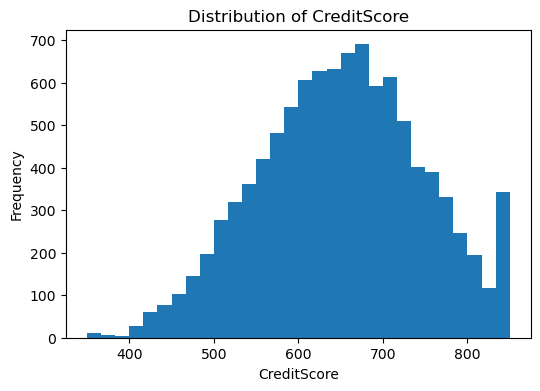

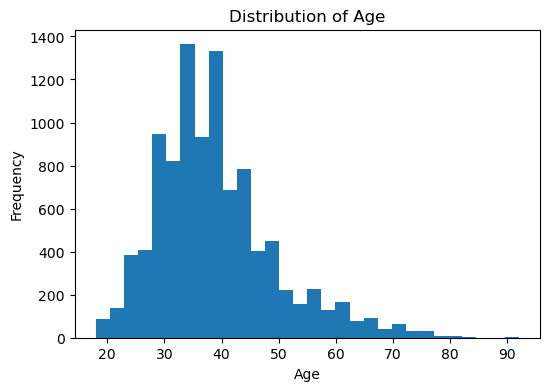

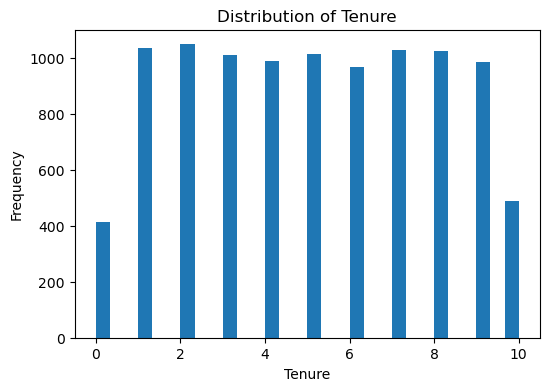

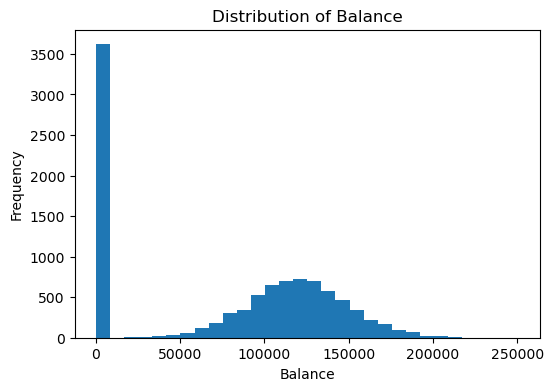

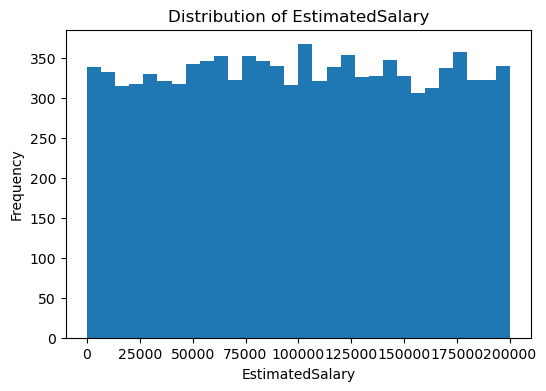

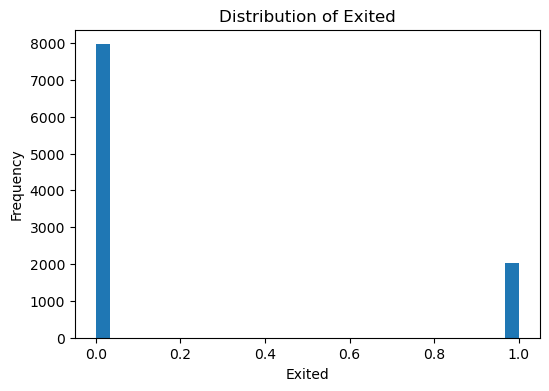

In [18]:
# Histograms for numerical columns
for col in numerical_columns:
    plt.figure(figsize=(6, 4))
    plt.hist(df_clean[col], bins=30)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

/var/folders/2t/52v3zvcs07993ghmllfrbxnw0000gn/T/ipykernel_68502/2660311584.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([data_stayed, data_churned], labels=['Stayed', 'Churned'])


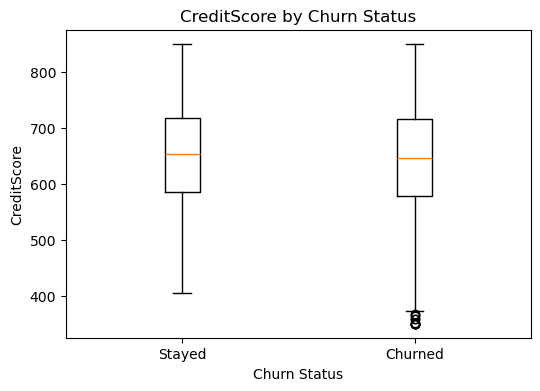

/var/folders/2t/52v3zvcs07993ghmllfrbxnw0000gn/T/ipykernel_68502/2660311584.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([data_stayed, data_churned], labels=['Stayed', 'Churned'])


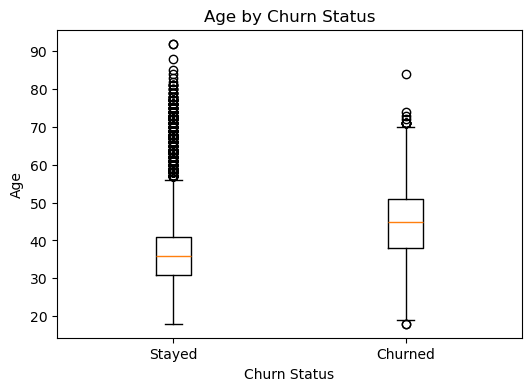

/var/folders/2t/52v3zvcs07993ghmllfrbxnw0000gn/T/ipykernel_68502/2660311584.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([data_stayed, data_churned], labels=['Stayed', 'Churned'])


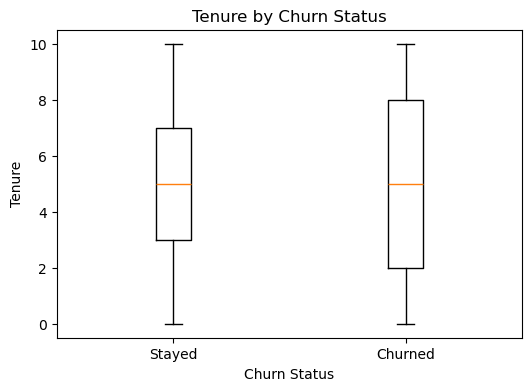

/var/folders/2t/52v3zvcs07993ghmllfrbxnw0000gn/T/ipykernel_68502/2660311584.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([data_stayed, data_churned], labels=['Stayed', 'Churned'])


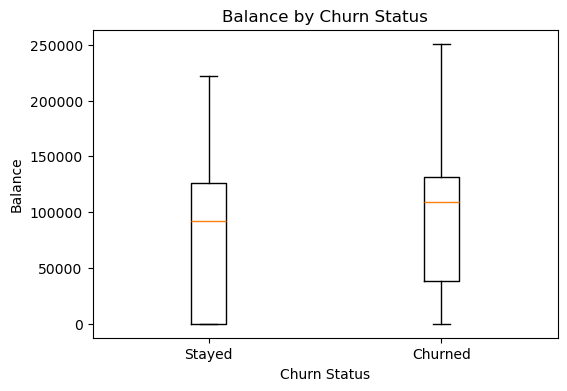

/var/folders/2t/52v3zvcs07993ghmllfrbxnw0000gn/T/ipykernel_68502/2660311584.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([data_stayed, data_churned], labels=['Stayed', 'Churned'])


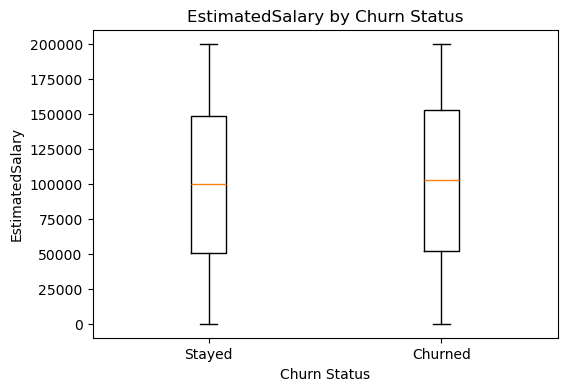

In [19]:
# Compare selected numerical features by churn status
features_to_compare = ['CreditScore', 'Age', 'Tenure', 'Balance', 'EstimatedSalary']

for col in features_to_compare:
    plt.figure(figsize=(6, 4))
    data_stayed = df_clean[df_clean['Exited'] == 0][col]
    data_churned = df_clean[df_clean['Exited'] == 1][col]
    plt.boxplot([data_stayed, data_churned], labels=['Stayed', 'Churned'])
    plt.title(f'{col} by Churn Status')
    plt.xlabel('Churn Status')
    plt.ylabel(col)
    plt.show()

## 8. Correlation Analysis

Correlation analysis helps identify relationships between numerical features and the target variable. This can also reveal highly correlated independent variables that may require further review.

In [20]:
# Correlation matrix for numeric columns
corr_matrix = df_clean.corr(numeric_only=True)
corr_matrix

,CreditScore,Age,Tenure,Balance,EstimatedSalary,Exited
CreditScore,1.00,-0.00,0.00,0.01,-0.00,-0.03
Age,-0.00,1.00,-0.01,0.03,-0.01,0.29
Tenure,0.00,-0.01,1.00,-0.01,0.01,-0.01
Balance,0.01,0.03,-0.01,1.00,0.01,0.12
EstimatedSalary,-0.00,-0.01,0.01,0.01,1.00,0.01
Exited,-0.03,0.29,-0.01,0.12,0.01,1.00


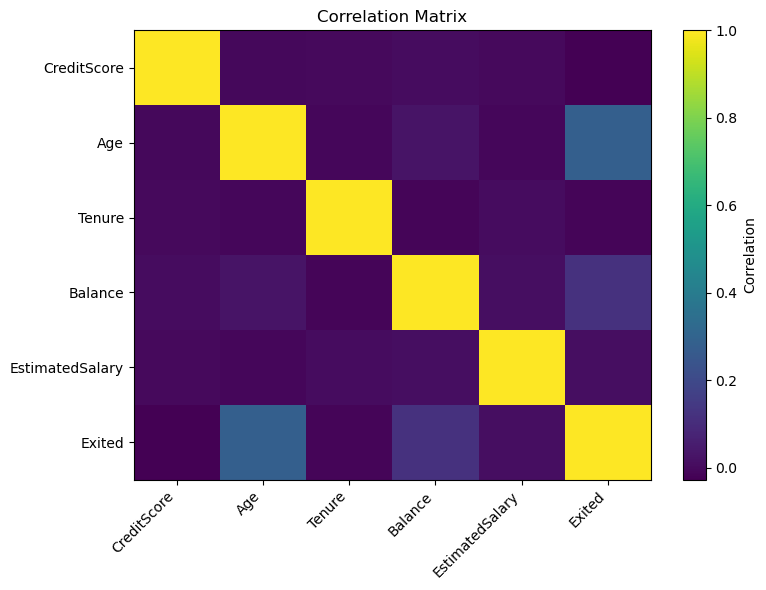

In [21]:
# Correlation heatmap using Matplotlib
plt.figure(figsize=(8, 6))
plt.imshow(corr_matrix, cmap='viridis', aspect='auto')
plt.colorbar(label='Correlation')
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=45, ha='right')
plt.yticks(range(len(corr_matrix.index)), corr_matrix.index)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

In [22]:
# Correlation with target variable
corr_with_target = corr_matrix['Exited'].sort_values(ascending=False)
corr_with_target

Exited             1.00
Age                0.29
Balance            0.12
EstimatedSalary    0.01
Tenure            -0.01
CreditScore       -0.03
Name: Exited, dtype: float64

## 9. Outlier Review

Outliers are reviewed using the interquartile range (IQR) method. At this stage, potential outliers are identified but not automatically removed. In business datasets, extreme values such as high balances, older ages, or unusual salaries may represent real customers rather than data errors.

In [23]:
# IQR-based outlier count for numerical predictors
outlier_summary = []

for col in ['CreditScore', 'Age', 'Tenure', 'Balance', 'EstimatedSalary']:
    q1 = df_clean[col].quantile(0.25)
    q3 = df_clean[col].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    outlier_count = ((df_clean[col] < lower_bound) | (df_clean[col] > upper_bound)).sum()
    outlier_percent = (outlier_count / len(df_clean)) * 100
    
    outlier_summary.append({
        'Feature': col,
        'Lower Bound': lower_bound,
        'Upper Bound': upper_bound,
        'Outlier Count': outlier_count,
        'Outlier Percentage': round(outlier_percent, 2)
    })

outlier_summary_df = pd.DataFrame(outlier_summary)
outlier_summary_df

,Feature,Lower Bound,Upper Bound,Outlier Count,Outlier Percentage
0,CreditScore,383.00,919.00,15,0.15
1,Age,14.00,62.00,359,3.59
2,Tenure,-3.00,13.00,0,0.00
3,Balance,"-191,466.36","319,110.60",0,0.00
4,EstimatedSalary,"-96,577.10","296,967.45",0,0.00


### Outlier Handling Decision

Potential outliers are retained in the cleaned dataset. The values appear plausible for banking customers and may contain useful churn signals. Removing them without evidence of data entry errors could reduce the model's ability to identify meaningful high-risk customer segments.

## 10. Encode Categorical Variables

Machine learning models require numerical input, so categorical variables are encoded using one-hot encoding. One category is dropped for each encoded feature to avoid redundant columns.

In [24]:
# One-hot encode categorical variables
df_encoded = pd.get_dummies(
    df_clean,
    columns=['Geography', 'Gender'],
    drop_first=True,
    dtype=int
)

df_encoded.head()

,CreditScore,Age,Tenure,Balance,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,844,18,2,"160,980.03","145,936.28",0,0,0,1
1,656,18,10,"151,762.74","127,014.32",0,0,0,1
2,570,18,4,"82,767.42","71,811.90",0,0,0,0
3,716,18,3,"128,743.80","197,322.13",0,1,0,0
4,727,18,4,"133,550.67","46,941.41",0,0,0,1


In [25]:
# Confirm all columns are numeric after encoding
df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CreditScore        10000 non-null  int64  
 1   Age                10000 non-null  int64  
 2   Tenure             10000 non-null  int64  
 3   Balance            10000 non-null  float64
 4   EstimatedSalary    10000 non-null  float64
 5   Exited             10000 non-null  int64  
 6   Geography_Germany  10000 non-null  int64  
 7   Geography_Spain    10000 non-null  int64  
 8   Gender_Male        10000 non-null  int64  
dtypes: float64(2), int64(7)
memory usage: 703.3 KB


## 11. Optional Feature Scaling Preview

Feature scaling is often useful for algorithms such as Logistic Regression, SVMs, and neural networks. Tree-based models such as Random Forest usually do not require scaling. Scaling will be applied during model training using a pipeline to avoid data leakage, but this section demonstrates which numerical features are candidates for scaling.

In [26]:
# Features that may benefit from scaling in future model pipelines
scaling_candidates = ['CreditScore', 'Age', 'Tenure', 'Balance', 'EstimatedSalary']
scaling_candidates

['CreditScore', 'Age', 'Tenure', 'Balance', 'EstimatedSalary']

## 12. Final Cleaned Dataset

The cleaned dataset is now ready for model development. It contains only predictive features and the target variable, with categorical features converted into numerical format.

In [27]:
# Final dataset shape and preview
print(f'Final cleaned dataset shape: {df_encoded.shape}')
df_encoded.head()

Final cleaned dataset shape: (10000, 9)


,CreditScore,Age,Tenure,Balance,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,844,18,2,"160,980.03","145,936.28",0,0,0,1
1,656,18,10,"151,762.74","127,014.32",0,0,0,1
2,570,18,4,"82,767.42","71,811.90",0,0,0,0
3,716,18,3,"128,743.80","197,322.13",0,1,0,0
4,727,18,4,"133,550.67","46,941.41",0,0,0,1


In [28]:
# Save cleaned dataset for future modeling notebooks
output_path = 'customer_churn_cleaned.csv'
df_encoded.to_csv(output_path, index=False)

print(f'Cleaned dataset saved to: {output_path}')

Cleaned dataset saved to: customer_churn_cleaned.csv


## 13. Data Wrangling Summary

The following data wrangling steps were completed:

1. Loaded the raw customer churn dataset.
2. Inspected the dataset shape, columns, data types, and summary statistics.
3. Checked for missing values and duplicate records.
4. Reviewed the target variable distribution and identified class imbalance.
5. Removed non-predictive identifier columns: `RowNumber`, `CustomerId`, and `Surname`.
6. Explored categorical variables including `Geography` and `Gender`.
7. Explored numerical feature distributions and churn relationships.
8. Reviewed potential outliers using the IQR method.
9. Retained outliers because they appear to represent plausible customer records rather than data errors.
10. Encoded categorical variables using one-hot encoding.
11. Exported a cleaned dataset for future model development.

The dataset is now prepared for baseline modeling and model comparison in the next capstone steps.